In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer



In [2]:
# Load dataset
df = pd.read_csv("Reviews.csv")

# Keep only necessary columns
df = df[['Score', 'Text']].dropna()

# Optional: Balance dataset (binary sentiment: 1 = negative, 0 = positive)
df = df[df['Score'] != 3]  # remove neutral
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

# Vectorize
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Sentiment']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Machine Learning Models

# 1. Logistic Regression

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.84      0.67      0.74     16379
           1       0.94      0.98      0.96     88784

    accuracy                           0.93    105163
   macro avg       0.89      0.82      0.85    105163
weighted avg       0.93      0.93      0.93    105163



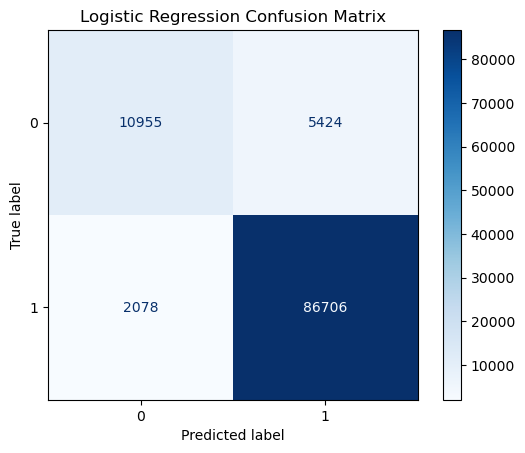

In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Classification Report
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)

# Support Vector Machine (SVM)

SVM Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.76     16379
           1       0.95      0.97      0.96     88784

    accuracy                           0.93    105163
   macro avg       0.89      0.83      0.86    105163
weighted avg       0.93      0.93      0.93    105163



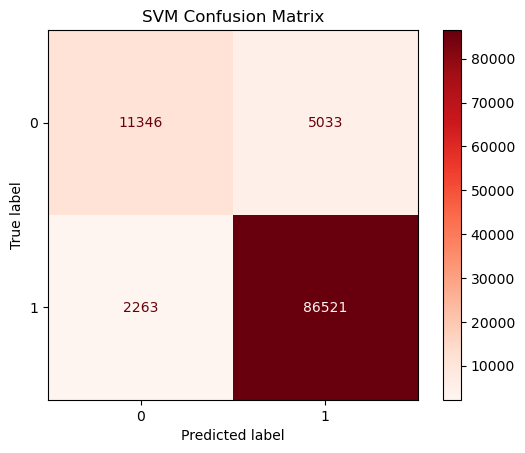

In [6]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Report:\n", classification_report(y_test, y_pred_svm))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot(cmap='Reds')
plt.title("SVM Confusion Matrix")
plt.show()

acc_svm = accuracy_score(y_test, y_pred_svm)

In [8]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/150.0 MB 4.8 MB/s eta 0:00:32
   ---------------------------------------- 1.8/150.0 MB 4.8 MB/s eta 0:00:31
    --------------------------------------- 2.6/150.0 MB 4.6 MB/s eta 0:00:33
    --------------------------------------- 3.4/150.0 MB 4.4 MB/s eta 0:00:34
   - -------------------------------------- 3.9/150.0 MB 4.1 MB/s eta 0:00:37
   - -------------------------------------- 5.0/150.0 MB 4.2 MB/s eta 0:00:35
   - -------------------------------------- 5.5/150.0 MB 4.1 MB/s eta 0:00:35
   - -------------------------------------- 6.8/150.0 MB 4.1 MB/s eta 0:00:35
   -- ------------------------------------- 7.6/150.0 MB 4.1 MB/s eta 0:00:35
   -- ------------------------------------- 8.4/150.0 MB 4.1 MB/s eta 0:00:35
   -- ------------------------------------- 8.7/150.0 MB 4.0 MB/s eta 0

C:\Users\ATHAK\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:36:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:
               precision    recall  f1-score   support

           0       0.88      0.53      0.66     16379
           1       0.92      0.99      0.95     88784

    accuracy                           0.92    105163
   macro avg       0.90      0.76      0.81    105163
weighted avg       0.91      0.92      0.91    105163



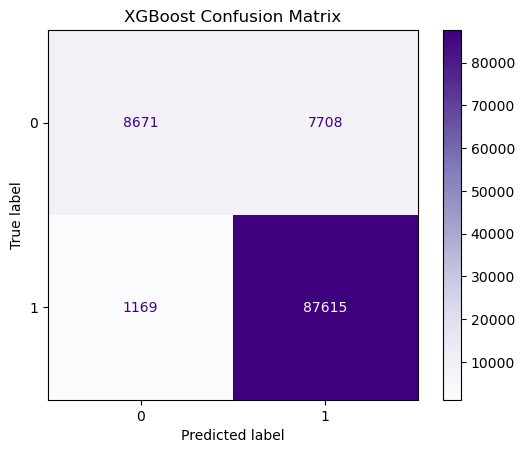

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot(cmap='Purples')
plt.title("XGBoost Confusion Matrix")
plt.show()

acc_xgb = accuracy_score(y_test, y_pred_xgb)

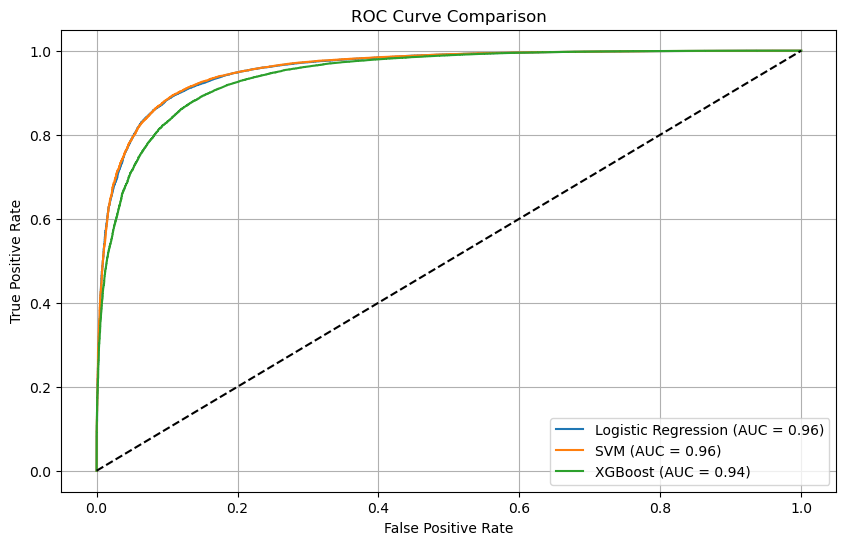

In [10]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_proba_svm = svm.decision_function(X_test)  # SVM doesn't use predict_proba

# Calculate ROC curves and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

# Plot all
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc(fpr_svm, tpr_svm):.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [13]:
import joblib

In [14]:
# Initialize models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Training, prediction, and saving
results = []
roc_data = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred  # fallback

    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    results.append({'Model': name, 'Accuracy': acc})
    roc_data[name] = (fpr, tpr, auc_score)

    # Save model
    joblib.dump(model, f"{name.lower()}_sentiment_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save comparison table
comparison_df = pd.DataFrame(results)
comparison_df.to_csv("model_comparison.csv", index=False)
print("\nModel comparison saved to 'model_comparison.csv':")
print(comparison_df)

Training LogisticRegression...
Training SVM...
Training XGBoost...


C:\Users\ATHAK\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:49:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model comparison saved to 'model_comparison.csv':
                Model  Accuracy
0  LogisticRegression  0.928663
1                 SVM  0.930622
2             XGBoost  0.915588
